<a href="https://colab.research.google.com/github/rht1419/Supply_Chain_Management_System_Poweredby_DL/blob/main/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
#importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
#data ingestion
file_path = "/content/US_Regional_Sales_Data.csv"
with open(file_path,'r')as file:
  df = pd.read_csv(file_path )

df.head(2)

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,SO - 000101,In-Store,WARE-UHY1004,31/12/17,31/5/18,14/6/18,19/6/18,USD,6,15,259,12,5,0.08,"$1,001.18","$1,963.10"
1,SO - 000102,Online,WARE-NMK1003,31/12/17,31/5/18,22/6/18,2/7/2018,USD,14,20,196,27,3,0.08,"$3,348.66","$3,939.60"


In [90]:
#checking the null values
df.isnull().sum()

,0
OrderNumber,0
Sales Channel,0
WarehouseCode,0
ProcuredDate,0
OrderDate,0
ShipDate,0
DeliveryDate,0
CurrencyCode,0
_SalesTeamID,0
_CustomerID,0


In [91]:
#checking duplicates
df.duplicated().sum()

np.int64(0)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderNumber       7991 non-null   object 
 1   Sales Channel     7991 non-null   object 
 2   WarehouseCode     7991 non-null   object 
 3   ProcuredDate      7991 non-null   object 
 4   OrderDate         7991 non-null   object 
 5   ShipDate          7991 non-null   object 
 6   DeliveryDate      7991 non-null   object 
 7   CurrencyCode      7991 non-null   object 
 8   _SalesTeamID      7991 non-null   int64  
 9   _CustomerID       7991 non-null   int64  
 10  _StoreID          7991 non-null   int64  
 11  _ProductID        7991 non-null   int64  
 12  Order Quantity    7991 non-null   int64  
 13  Discount Applied  7991 non-null   float64
 14  Unit Cost         7991 non-null   object 
 15  Unit Price        7991 non-null   object 
dtypes: float64(1), int64(5), object(10)
memory

In [93]:
df.columns

Index(['OrderNumber', 'Sales Channel', 'WarehouseCode', 'ProcuredDate',
       'OrderDate', 'ShipDate', 'DeliveryDate', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID', '_ProductID', 'Order Quantity',
       'Discount Applied', 'Unit Cost', 'Unit Price'],
      dtype='object')

In [94]:
df = df.drop(columns=['OrderNumber', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID'])

In [95]:
#shape
df.shape

(7991, 11)

In [96]:
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,In-Store,WARE-UHY1004,31/12/17,31/5/18,14/6/18,19/6/18,12,5,0.08,"$1,001.18","$1,963.10"
1,Online,WARE-NMK1003,31/12/17,31/5/18,22/6/18,2/7/2018,27,3,0.08,"$3,348.66","$3,939.60"
2,Distributor,WARE-UHY1004,31/12/17,31/5/18,21/6/18,1/7/2018,16,1,0.05,$781.22,"$1,775.50"
3,Wholesale,WARE-NMK1003,31/12/17,31/5/18,2/6/2018,7/6/2018,23,8,0.08,"$1,464.69","$2,324.90"
4,Distributor,WARE-NMK1003,10/4/2018,31/5/18,16/6/18,26/6/18,26,8,0.10,"$1,476.14","$1,822.40"


In [97]:
#Coverting order date to proper date format
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

/tmp/ipykernel_3742/4228028293.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'])


In [98]:
#Checking the datatype of OrderDate
df['OrderDate'].dtype

dtype('<M8[ns]')

In [99]:
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,In-Store,WARE-UHY1004,31/12/17,2018-05-31,14/6/18,19/6/18,12,5,0.08,"$1,001.18","$1,963.10"
1,Online,WARE-NMK1003,31/12/17,2018-05-31,22/6/18,2/7/2018,27,3,0.08,"$3,348.66","$3,939.60"
2,Distributor,WARE-UHY1004,31/12/17,2018-05-31,21/6/18,1/7/2018,16,1,0.05,$781.22,"$1,775.50"
3,Wholesale,WARE-NMK1003,31/12/17,2018-05-31,2/6/2018,7/6/2018,23,8,0.08,"$1,464.69","$2,324.90"
4,Distributor,WARE-NMK1003,10/4/2018,2018-05-31,16/6/18,26/6/18,26,8,0.10,"$1,476.14","$1,822.40"


In [138]:
#Grouping by Date with Product → sum of Order Quantity per day
daily_sales = df.groupby(['OrderDate','_ProductID'])['Order Quantity'].sum().reset_index()

In [101]:
df.head()


,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,In-Store,WARE-UHY1004,31/12/17,2018-05-31,14/6/18,19/6/18,12,5,0.08,"$1,001.18","$1,963.10"
1,Online,WARE-NMK1003,31/12/17,2018-05-31,22/6/18,2/7/2018,27,3,0.08,"$3,348.66","$3,939.60"
2,Distributor,WARE-UHY1004,31/12/17,2018-05-31,21/6/18,1/7/2018,16,1,0.05,$781.22,"$1,775.50"
3,Wholesale,WARE-NMK1003,31/12/17,2018-05-31,2/6/2018,7/6/2018,23,8,0.08,"$1,464.69","$2,324.90"
4,Distributor,WARE-NMK1003,10/4/2018,2018-05-31,16/6/18,26/6/18,26,8,0.10,"$1,476.14","$1,822.40"


In [102]:
#Extracting from OrderDate -> Day of weak by datetimeaccesser
from sklearn.preprocessing import OrdinalEncoder
df['day_of_week'] = df['OrderDate'].dt.day_name()

ord_day = OrdinalEncoder(
    categories=[['Monday', 'Tuesday', 'Wednesday', 'Thursday',
                 'Friday', 'Saturday', 'Sunday']]
)

df['day_of_week'] = ord_day.fit_transform(df[['day_of_week']])

In [103]:
# month
df['month'] = df['OrderDate'].dt.month_name()

ord_month = OrdinalEncoder(
    categories=[[
        'January', 'February', 'March', 'April',
        'May', 'June', 'July', 'August',
        'September', 'October', 'November', 'December'
    ]]
)

df['month'] = ord_month.fit_transform(df[['month']])

In [104]:
#quarter
df['quarter'] = df['OrderDate'].dt.quarter

In [105]:
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price,day_of_week,month,quarter
0,In-Store,WARE-UHY1004,31/12/17,2018-05-31,14/6/18,19/6/18,12,5,0.08,"$1,001.18","$1,963.10",3.0,4.0,2
1,Online,WARE-NMK1003,31/12/17,2018-05-31,22/6/18,2/7/2018,27,3,0.08,"$3,348.66","$3,939.60",3.0,4.0,2
2,Distributor,WARE-UHY1004,31/12/17,2018-05-31,21/6/18,1/7/2018,16,1,0.05,$781.22,"$1,775.50",3.0,4.0,2
3,Wholesale,WARE-NMK1003,31/12/17,2018-05-31,2/6/2018,7/6/2018,23,8,0.08,"$1,464.69","$2,324.90",3.0,4.0,2
4,Distributor,WARE-NMK1003,10/4/2018,2018-05-31,16/6/18,26/6/18,26,8,0.10,"$1,476.14","$1,822.40",3.0,4.0,2


In [106]:
df['quarter'] = df['OrderDate'].dt.quarter

In [107]:
df['year'] = df['OrderDate'].dt.year

In [108]:
df['is_weekend'] = df['OrderDate'].dt.dayofweek >= 5

In [109]:
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price,day_of_week,month,quarter,year,is_weekend
0,In-Store,WARE-UHY1004,31/12/17,2018-05-31,14/6/18,19/6/18,12,5,0.08,"$1,001.18","$1,963.10",3.0,4.0,2,2018,False
1,Online,WARE-NMK1003,31/12/17,2018-05-31,22/6/18,2/7/2018,27,3,0.08,"$3,348.66","$3,939.60",3.0,4.0,2,2018,False
2,Distributor,WARE-UHY1004,31/12/17,2018-05-31,21/6/18,1/7/2018,16,1,0.05,$781.22,"$1,775.50",3.0,4.0,2,2018,False
3,Wholesale,WARE-NMK1003,31/12/17,2018-05-31,2/6/2018,7/6/2018,23,8,0.08,"$1,464.69","$2,324.90",3.0,4.0,2,2018,False
4,Distributor,WARE-NMK1003,10/4/2018,2018-05-31,16/6/18,26/6/18,26,8,0.10,"$1,476.14","$1,822.40",3.0,4.0,2,2018,False


In [110]:
df['ProcuredDate'] = pd.to_datetime(df['ProcuredDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])

/tmp/ipykernel_3742/2598566015.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ProcuredDate'] = pd.to_datetime(df['ProcuredDate'])
/tmp/ipykernel_3742/2598566015.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])


In [111]:
df['lead_time_days'] = (
    df['DeliveryDate'] - df['ProcuredDate']
).dt.days

In [114]:
df['is_discounted'] = df['Discount Applied'] > 0


In [140]:
df.head()

,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price,day_of_week,month,quarter,year,is_weekend,lead_time_days,is_discounted,Revenue
0,In-Store,WARE-UHY1004,2017-12-31,2018-05-31,14/6/18,2018-06-19,12,5,0.08,"$1,001.18",1963.1,3.0,4.0,2,2018,False,170,True,9815.5
1,Online,WARE-NMK1003,2017-12-31,2018-05-31,22/6/18,2018-02-07,27,3,0.08,"$3,348.66",3939.6,3.0,4.0,2,2018,False,38,True,11818.8
2,Distributor,WARE-UHY1004,2017-12-31,2018-05-31,21/6/18,2018-01-07,16,1,0.05,$781.22,1775.5,3.0,4.0,2,2018,False,7,True,1775.5
3,Wholesale,WARE-NMK1003,2017-12-31,2018-05-31,2/6/2018,2018-07-06,23,8,0.08,"$1,464.69",2324.9,3.0,4.0,2,2018,False,187,True,18599.2
4,Distributor,WARE-NMK1003,2018-10-04,2018-05-31,16/6/18,2018-06-26,26,8,0.10,"$1,476.14",1822.4,3.0,4.0,2,2018,False,-100,True,14579.2


In [134]:
df.drop(['Revenue'],axis=1,inplace=True)

In [136]:
# Check Unit Price values
df['Unit Price'].head()

,Unit Price
0,1963.1
1,3939.6
2,1775.5
3,2324.9
4,1822.4


In [137]:
# Calculate Revenue
df['Revenue'] = df['Order Quantity'] * df['Unit Price']

In [142]:
# Select one product
product_id = 12

In [146]:
daily_sales = daily_sales[daily_sales['_ProductID'] == product_id]


In [147]:
# Sort data by OrderDate
daily_sales = daily_sales.sort_values('OrderDate')

In [149]:
#Normalization of order quantity
from sklearn.preprocessing import MinMaxScaler

# Scale Order Quantity
scaler = MinMaxScaler()

daily_sales['Order Quantity'] = scaler.fit_transform(
    daily_sales[['Order Quantity']]
)

In [150]:
# Create sequences for LSTM
sequence_length = 30
forecast_days = 7

In [151]:
## Create input and output sequences
X = []
y = []

for i in range(sequence_length, len(daily_sales) - forecast_days + 1):
    X.append(daily_sales['Order Quantity'].values[i-sequence_length:i])
    y.append(daily_sales['Order Quantity'].values[i:i+forecast_days])

In [152]:
# Convert sequences to NumPy arrays
X = np.array(X)
y = np.array(y)

In [153]:
# Reshape X for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)

In [154]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [156]:
##Training the LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
model = Sequential()

model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(7))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [157]:
# Compile the LSTM model
model.compile(
    optimizer='adam',
    loss='mse'
)

In [158]:
# Train the LSTM model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.2028 - val_loss: 0.1382
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1531 - val_loss: 0.1030
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1054 - val_loss: 0.0753
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0756 - val_loss: 0.0908
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0765 - val_loss: 0.0714
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0672 - val_loss: 0.0694
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0671 - val_loss: 0.0693
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0651 - val_loss: 0.0713
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0628 - val_loss: 0.0724
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0631 - val_loss: 0.0721
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0615 - val_loss: 0.0711
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0631 - val_loss: 0.0705


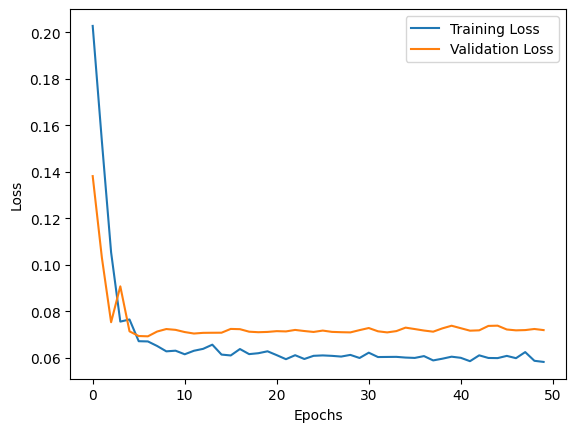

In [159]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [162]:
# Make predictions on test data
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step


In [163]:
# Convert predictions back to original sales values
y_pred_actual = scaler.inverse_transform(
    y_pred.reshape(-1, 1)
).reshape(y_pred.shape)

y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

In [175]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
))

# Calculate MAPE
mape = mean_absolute_percentage_error(
    y_test_actual.flatten(),
    y_pred_actual.flatten()
) * 100

print("RMSE:", rmse)
print("MAPE:", mape, "%")

RMSE: 0.2682267221964671
MAPE: 3.750148770004823e+16 %
